# e14 scaling campaign — accuracy improvements (v2 → v3, GT arm vs edges arm)

**Date:** 2026-08-10 · **wandb tag:** `e14_scaling` · **model:** `google/gemma-4-31B-it`, LoRA, lr 2.5e-4

The e14 campaign scaled nav-planning training off the old p152 suite and onto freshly generated
`n=60` graph corpora, to find out whether the **learned graph channel** (GT navigator Psi injected
through the graph channel) survives at realistic graph sizes — and how it compares to the trivial
bracket of just **writing the edge list into the prompt text**.

Three things moved over the campaign:

1. **v2 corpora (`n_{30,60}_vllm_v2`)** — clean rename-map populate contract, 26 train + 7 test
   graphs, 10 tasks/graph. Three arms per size: *floor* (node names, no connectivity anywhere),
   *edges-in-prompt*, and the *GT graph channel*. Result: the channel is a large real gain over the
   floor at both sizes, but text edges beat it at both, and the gap explodes with scale
   (n30 1.4×, n60 **8.2×**).
2. **v3 corpus (`n_60_vllm_v3`, widened)** — the data lever. 52 new train graphs (seeds 201–252,
   topologically disjoint from the frozen test set) ≈ 2× the training conversations, plus **2 extra
   long-hop Navigability tasks per graph** (12 tasks/graph, hop length sampled uniform over
   [3, diameter]). The 7 v2 test graphs were carried over frozen, so their original 10 tasks form a
   **legacy-10 subset** that compares directly against v2.
3. **Epoch extension** — the v3 GT arm was still climbing at the 3-epoch cutoff, so the identical
   recipe was rerun with `EPOCHS=6` to find that arm's actual ceiling.

Sources (the docs win on any conflict with this notebook):
`docs/2026-08-07 e14_scaling_v2_results.md`, `docs/2026-08-08 e14_scaling_v3_n60_widened_corpus.md`.

## Summary table

One row per training run. Accuracies are **in-training eval** (the `EvalCallback` path) unless the
column says reload; never mix the two paths inside one comparison.

In [1]:
# All numbers hardcoded from the campaign docs (do NOT re-derive or parse at runtime):
#   docs/2026-08-07 e14_scaling_v2_results.md            -> v2 rows (section 2 headline table)
#   docs/2026-08-08 e14_scaling_v3_n60_widened_corpus.md -> v3 rows (Results + 6-epoch results)
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", None)  # keep the notes column readable

RUNS = [
    # ---- v2 corpora, 3 epochs, 70 eval samples (7 test graphs x 10 tasks) ----
    dict(label="v2 n30 floor", corpus="v2 n30", arm="floor (no edges)", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.157, reload_acc=None,
         legacy10=0.157, longhop=None, halluc=0.537, job_run="7437500 / e07f6180",
         notes="context row (n30); no connectivity in prompt or channel"),
    dict(label="v2 n30 GT", corpus="v2 n30", arm="GT graph channel", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.700, reload_acc=0.729,
         legacy10=0.700, longhop=None, halluc=0.089, job_run="7437502 / 8g2o6yzd",
         notes="context row (n30); reload 0.729 is the fixed-path probe 7439396"),
    dict(label="v2 n30 edges", corpus="v2 n30", arm="edges-in-prompt", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.986, reload_acc=None,
         legacy10=0.986, longhop=None, halluc=0.005, job_run="7437559 / krktnvkr",
         notes="context row (n30); already at ceiling by epoch 0.92"),
    dict(label="v2 n60 floor", corpus="v2 n60", arm="floor (no edges)", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.029, reload_acc=None,
         legacy10=0.029, longhop=None, halluc=0.570, job_run="7437501 / 32na8lx2",
         notes="~chance; invents a generic hub topology (pure prior)"),
    dict(label="v2 n60 GT 3ep", corpus="v2 n60", arm="GT graph channel", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="flat from epoch 1", final_acc=0.114, reload_acc=0.200,
         legacy10=0.114, longhop=None, halluc=0.222, job_run="7437503 / q91esr6a",
         notes="the collapse v3 was built to attack; fixed-path 2x2 = train 0.429 / test 0.200 (47% retention)"),
    dict(label="v2 n60 edges 3ep", corpus="v2 n60", arm="edges-in-prompt", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.943, reload_acc=None,
         legacy10=0.943, longhop=None, halluc=0.015, job_run="7438021 / iq8bo4sa",
         notes="text bracket barely moves n30 -> n60 (0.986 -> 0.943)"),
    # ---- v3 widened corpus, 84 eval samples (7 frozen test graphs x 12 tasks) ----
    dict(label="v3 n60 GT 3ep", corpus="v3 n60 widened", arm="GT graph channel", epochs=3, lr=2.5e-4,
         eval_n=84, epoch_traj="0.286 -> 0.357 -> 0.393", final_acc=0.393, reload_acc=0.440,
         legacy10=0.457, longhop="1/14", halluc=0.084, job_run="7439956 / kma1nipe",
         notes="3.4x over v2 GT on a harder set, 4x on legacy-10; retention 47% -> 70%; still climbing at cutoff"),
    dict(label="v3 n60 GT 6ep", corpus="v3 n60 widened", arm="GT graph channel", epochs=6, lr=2.5e-4,
         eval_n=84, epoch_traj="0.321 -> 0.512 -> 0.464 -> 0.369 -> 0.560 -> 0.560",
         final_acc=0.560, reload_acc=0.500,
         legacy10=0.571, longhop="7/14", halluc=None, job_run="7464551 / n6dz4zlq",
         notes="PLATEAU value (epochs 5 and 6 identical at 47/84) - quote this, never a single epoch; "
               "10 OOM-crashed samples scored incorrect"),
    dict(label="v3 n60 edges 3ep", corpus="v3 n60 widened", arm="edges-in-prompt", epochs=3, lr=2.5e-4,
         eval_n=84, epoch_traj="0.726 -> 0.881 -> 0.952", final_acc=0.952, reload_acc=0.929,
         legacy10=0.957, longhop="13/14", halluc=0.011, job_run="7439955 / zqvzaab6",
         notes="effective ceiling; long-hop tasks are nearly free with edges in the prompt"),
]

# SPINE tools-enabled eval (2026-08-10, jobs 7475035/36/37/39). EVERY accuracy above
# was measured with SPINE tool-calling DISABLED (PRISM_DISABLE_SPINE_TOOLS=1) — the model
# writes a route directly, nothing executes. These are the tools-ENABLED counterpart on
# the SAME checkpoints and test graphs: the model may call the SPINE API actions against
# a live simulator while planning. Only the 4 arms below were re-run.
#   docs: v2 section 6 (n30 arms) / v3 "SPINE tools-enabled eval" (n60 arms)
SPINE = {
    # spine_goto = samples that emitted a goto call at all (out of those that produced a
    # trace). The calls are INERT - see the audit note below - but the rate is a real
    # behavioural signal: the edges arms always follow the documented output contract,
    # the GT arms drift away from it as graphs grow.
    "v2 n30 edges":     dict(spine_acc=0.986, spine_correct="69/70", spine_keyword="70/70", spine_errors=0, spine_goto="70/70", spine_job="7475035"),
    "v2 n30 GT":        dict(spine_acc=0.714, spine_correct="50/70", spine_keyword="62/70", spine_errors=2, spine_goto="42/68", spine_job="7475036"),
    "v3 n60 edges 3ep": dict(spine_acc=0.964, spine_correct="81/84", spine_keyword="84/84", spine_errors=0, spine_goto="84/84", spine_job="7475037"),
    "v3 n60 GT 6ep":    dict(spine_acc=0.476, spine_correct="40/84", spine_keyword="61/84", spine_errors=2, spine_goto="17/82", spine_job="7475039"),
}
_no_spine = dict(spine_acc=None, spine_correct=None, spine_keyword=None, spine_errors=None, spine_goto=None, spine_job=None)
for _r in RUNS:
    _r.update(SPINE.get(_r["label"], _no_spine))

df = pd.DataFrame(RUNS)[[
    "label", "corpus", "arm", "epochs", "lr", "eval_n", "epoch_traj",
    "final_acc", "reload_acc", "spine_acc", "legacy10", "longhop", "halluc", "job_run", "notes",
]].rename(columns={
    "label": "run", "eval_n": "eval N", "epoch_traj": "per-epoch eval acc",
    "final_acc": "final acc", "reload_acc": "reload acc", "spine_acc": "SPINE acc", "legacy10": "legacy-10 acc",
    "longhop": "long-hop", "halluc": "halluc rate", "job_run": "job / wandb",
})
df

,run,corpus,arm,epochs,lr,eval N,per-epoch eval acc,final acc,reload acc,SPINE acc,legacy-10 acc,long-hop,halluc rate,job / wandb,notes
0,v2 n30 floor,v2 n30,floor (no edges),3,0.00025,70,-,0.157,NaN,NaN,0.157,None,0.537,7437500 / e07f6180,context row (n30); no connectivity in prompt or channel
1,v2 n30 GT,v2 n30,GT graph channel,3,0.00025,70,-,0.700,0.729,0.714,0.700,None,0.089,7437502 / 8g2o6yzd,context row (n30); reload 0.729 is the fixed-path probe 7439396
2,v2 n30 edges,v2 n30,edges-in-prompt,3,0.00025,70,-,0.986,NaN,0.986,0.986,None,0.005,7437559 / krktnvkr,context row (n30); already at ceiling by epoch 0.92
3,v2 n60 floor,v2 n60,floor (no edges),3,0.00025,70,-,0.029,NaN,NaN,0.029,None,0.570,7437501 / 32na8lx2,~chance; invents a generic hub topology (pure prior)
4,v2 n60 GT 3ep,v2 n60,GT graph channel,3,0.00025,70,flat from epoch 1,0.114,0.200,NaN,0.114,None,0.222,7437503 / q91esr6a,the collapse v3 was built to attack; fixed-path 2x2 = train 0.429 / test 0.200 (47% retention)
5,v2 n60 edges 3ep,v2 n60,edges-in-prompt,3,0.00025,70,-,0.943,NaN,NaN,0.943,None,0.015,7438021 / iq8bo4sa,text bracket barely moves n30 -> n60 (0.986 -> 0.943)
6,v3 n60 GT 3ep,v3 n60 widened,GT graph channel,3,0.00025,84,0.286 -> 0.357 -> 0.393,0.393,0.440,NaN,0.457,1/14,0.084,7439956 / kma1nipe,"3.4x over v2 GT on a harder set, 4x on legacy-10; retention 47% -> 70%; still climbing at cutoff"
7,v3 n60 GT 6ep,v3 n60 widened,GT graph channel,6,0.00025,84,0.321 -> 0.512 -> 0.464 -> 0.369 -> 0.560 -> 0.560,0.560,0.500,0.476,0.571,7/14,NaN,7464551 / n6dz4zlq,"PLATEAU value (epochs 5 and 6 identical at 47/84) - quote this, never a single epoch; 10 OOM-crashed samples scored incorrect"
8,v3 n60 edges 3ep,v3 n60 widened,edges-in-prompt,3,0.00025,84,0.726 -> 0.881 -> 0.952,0.952,0.929,0.964,0.957,13/14,0.011,7439955 / zqvzaab6,effective ceiling; long-hop tasks are nearly free with edges in the prompt


In [2]:
# Notion-pasteable: run this cell, copy the printed markdown, paste into Notion (auto-converts to a table).
# Generated from df so it can never drift from the table above.
def md_cell(value):
    return "" if pd.isna(value) else str(value)

header = "| " + " | ".join(df.columns) + " |"
separator = "|" + "|".join([" --- "] * len(df.columns)) + "|"
body = ["| " + " | ".join(md_cell(v) for v in row) + " |" for row in df.itertuples(index=False)]
print("\n".join([header, separator, *body]))

| run | corpus | arm | epochs | lr | eval N | per-epoch eval acc | final acc | reload acc | SPINE acc | legacy-10 acc | long-hop | halluc rate | job / wandb | notes |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| v2 n30 floor | v2 n30 | floor (no edges) | 3 | 0.00025 | 70 | - | 0.157 |  |  | 0.157 |  | 0.537 | 7437500 / e07f6180 | context row (n30); no connectivity in prompt or channel |
| v2 n30 GT | v2 n30 | GT graph channel | 3 | 0.00025 | 70 | - | 0.7 | 0.729 | 0.714 | 0.7 |  | 0.089 | 7437502 / 8g2o6yzd | context row (n30); reload 0.729 is the fixed-path probe 7439396 |
| v2 n30 edges | v2 n30 | edges-in-prompt | 3 | 0.00025 | 70 | - | 0.986 |  | 0.986 | 0.986 |  | 0.005 | 7437559 / krktnvkr | context row (n30); already at ceiling by epoch 0.92 |
| v2 n60 floor | v2 n60 | floor (no edges) | 3 | 0.00025 | 70 | - | 0.029 |  |  | 0.029 |  | 0.57 | 7437501 / 32na8lx2 | ~chance; invents a generic hub topology (pure prior) |
| v2 n60 GT 3e

Column notes:

- **final acc** — in-training eval accuracy at the last epoch; for the 6-epoch GT run this is the
  *plateau* (epochs 5 = 6), not a best-epoch pick. **reload acc** is the post-train save→load
  round-trip (`eval.post_train_graphs`, first enabled on the v3 runs) or, for the v2 GT rows, the
  fixed-path reload probe after the 4-bit merge bug was fixed (`b378e5a`).
- **legacy-10 acc** — the original 10 tasks per frozen test graph (70 samples): the only
  apples-to-apples quantity across v2 and v3. For the v2 rows the eval set *is* the legacy-10 set,
  so it equals final acc.
- **long-hop** — the 2 extra Navigability tasks per graph added in v3 (14 samples); no v2 equivalent.
- All runs share lr 2.5e-4, `icl_examples=2`, full-test generation eval (`eval.num_graphs=-1`), one
  B200. The GT arms additionally carry Stage-1 SFT epochs the baselines do not — an asymmetry that
  favors GT, and it still trails the text bracket.
- **SPINE acc** — accuracy with SPINE tool-calling ENABLED, on the same checkpoint
  and the same test graphs. Blank where that arm was not re-run in the tools-on batch.
  Every other accuracy column is tools-OFF. Full per-arm detail (correct counts,
  keyword rates, eval crashes) is in the SPINE section further down.


## How to read these numbers (caveats that matter)

- **Quote the plateau, never a single epoch.** The 6-epoch GT run swings up to 0.19 between adjacent
  epochs (0.464 → 0.369 → 0.560), beyond the ±0.11 that 84-sample binomial noise explains. Epochs 5
  and 6 landing on exactly 47/84 is the plateau signature the run was built to detect; the epoch-4
  dip is the run's own volatility, not a regression.
- **Part of the 6ep-over-3ep gain is run-to-run variance.** The 6-epoch run's epoch 2 (0.512) reads
  +0.155 above the 3-epoch run's epoch 2 (0.357) on an identical recipe — beyond 2 SE. Training is
  not reproducible epoch-by-epoch. The epoch-5/6 plateau still sits ~3 SE above 0.393, so the
  direction holds, but do not read 0.393 → 0.560 as a clean "+0.167 from more epochs".
- **Crashed eval samples are scored incorrect** (`evaluate.py:389`). The 6-epoch run took 10 CUDA-OOM
  sample crashes (3/2/0/1/2/0 per epoch + 2 in the round trip) after three allocator/leak fixes; each
  costs ~0.02 worst case, so that run's numbers slightly **understate** it. Epoch 6 itself had 0
  crashes, so the plateau value needs no adjustment.
- **Never mix eval paths in one comparison.** Round-trip deltas are bidirectional
  (+0.048 / −0.024 / −0.060) — sampling noise on small evals, not a systematic reload bias. The v2
  headline table is in-training throughout; keep it that way.
- **v2 (70 samples, 10 tasks) and v3 (84 samples, 12 tasks) totals are not directly comparable** —
  v3 added the harder long-hop tasks. Use the legacy-10 column for the clean v2 ↔ v3 read.
- The doc reports no hallucination rate for the 6-epoch run (blank in the table).

## Accuracy over the campaign (n60 only)

The n30 rows above are context; the campaign's question lives at n60. Bars are ordered worst → best,
which for the GT arm also tracks the chronological narrative (v2 → v3 → v3 with more epochs).

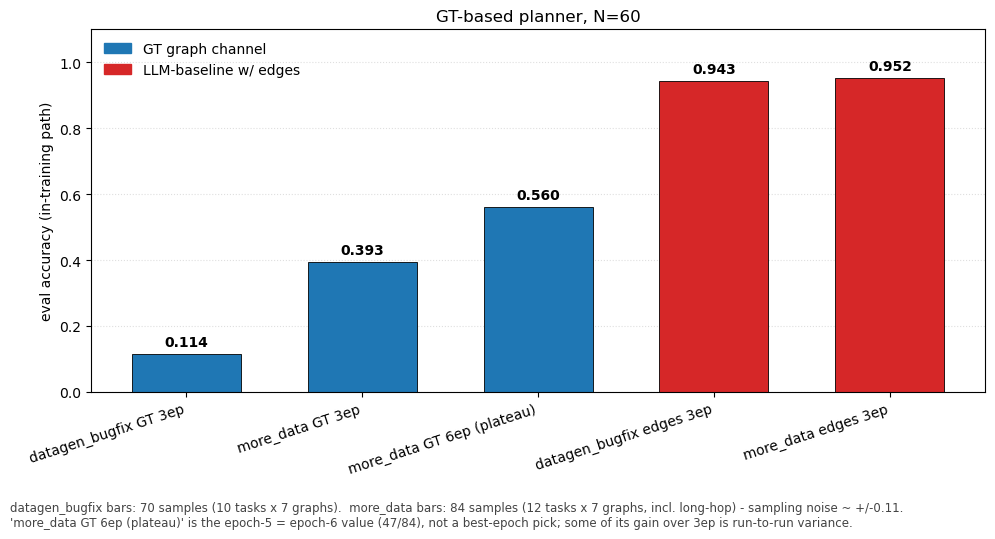

In [3]:
# n60 story only, worst -> best. Values are the "final acc" column above (in-training eval path).
PLOT_ROWS = [
    ("datagen_bugfix GT 3ep",      0.114, "GT"),
    ("more_data GT 3ep",           0.393, "GT"),
    ("more_data GT 6ep (plateau)", 0.560, "GT"),
    ("datagen_bugfix edges 3ep",   0.943, "edges"),
    ("more_data edges 3ep",        0.952, "edges"),
]
COLORS = {"GT": "#1f77b4", "edges": "#d62728"}

labels = [r[0] for r in PLOT_ROWS]
values = [r[1] for r in PLOT_ROWS]
colors = [COLORS[r[2]] for r in PLOT_ROWS]

fig, ax = plt.subplots(figsize=(10, 5.4))
bars = ax.bar(labels, values, color=colors, width=0.62, edgecolor="black", linewidth=0.6)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.10)
ax.set_ylabel("eval accuracy (in-training path)")
ax.set_title("GT-based planner, N=60")
ax.tick_params(axis="x", labelrotation=18)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[k]) for k in ["GT", "edges"]]
ax.legend(handles, ["GT graph channel", "LLM-baseline w/ edges"],
          loc="upper left", frameon=False)

fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.text(0.01, 0.015,
         "datagen_bugfix bars: 70 samples (10 tasks x 7 graphs).  more_data bars: 84 samples "
         "(12 tasks x 7 graphs, incl. long-hop) - sampling noise ~ +/-0.11.\n"
         "'more_data GT 6ep (plateau)' is the epoch-5 = epoch-6 value (47/84), not a best-epoch "
         "pick; some of its gain over 3ep is run-to-run variance.",
         fontsize=8.5, color="#444444", ha="left")
plt.show()

## SPINE tools-enabled eval (added 2026-08-10)

These four runs put the same checkpoints through the eval harness with SPINE tool-calling
**enabled** — the model may call the SPINE API actions (`goto`, `map_region`, ...) against
a live simulator while it plans — instead of the tool-free setting every number above uses.

> **⚠️ Audit result: these runs are effectively SINGLE-SHOT. Read this before quoting them.**
>
> Inspecting the rollout JSONs (`results/e14_spine_2026-08-10/`, pulled from betty) shows
> **307 of 308 samples used exactly one planner call.** The models emit
> `[goto(X), answer(route)]` as a *single* response — the answer is written before any tool
> result exists — and `goto` is a pure location update that reveals nothing by design
> (`graph_sim.take_action`; only `map_region` / `explore_region` / `inspect` return
> information). So the executed call yields no updates, the loop terminates on the `answer`
> in that same response, and what gets graded is one greedy generation, exactly as in the
> tools-off eval. Precisely **one** sample in the whole batch (n30 edges, `data_gen_011`
> idx 4) called `inspect`, got real feedback back, and produced a genuine second turn.
>
> So this is a **prompt-format ablation** — does adding the SPINE tool documentation to the
> prompt change accuracy? — **not** a test of interactive planning. Nothing here supports
> (or refutes) a claim about whether tool *use* would help the graph channel. The likely
> reason the models never explore: the prompt already contains the complete scene graph,
> so there is nothing left to discover.


,job,tools OFF,tools ON,delta (pts),correct,keyword,eval crashes,emitted goto
arm,,,,,,,,
n30 GT,7475036,0.700,0.714,1.4,50/70,62/70,2.0,42/68
n30 edges,7475035,0.986,0.986,0.0,69/70,70/70,0.0,70/70
n60 GT 6ep,7475039,0.560,0.476,-8.4,40/84,61/84,2.0,17/82
n60 edges,7475037,0.952,0.964,1.2,81/84,84/84,0.0,84/84


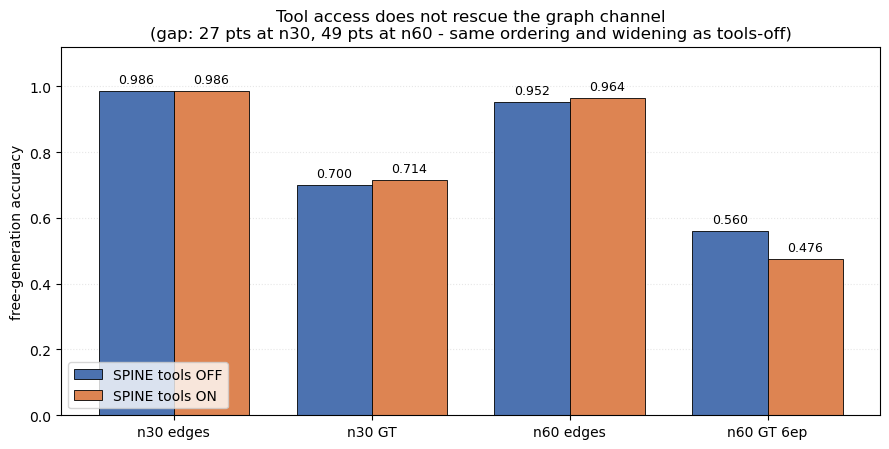

In [4]:
# Tools-off vs tools-on, for the 4 arms re-run in the SPINE batch.
# Built from RUNS (not the projected df) so the SPINE detail columns are available.
spine = pd.DataFrame(RUNS)
spine = spine[spine["spine_acc"].notna()].copy()
spine["short"] = (spine["label"].str.replace(r"^v[23] ", "", regex=True)
                                .str.replace(" 3ep", "", regex=False))
spine["delta"] = ((spine["spine_acc"] - spine["final_acc"]) * 100).round(1)

detail = spine[["short", "spine_job", "final_acc", "spine_acc", "delta",
                "spine_correct", "spine_keyword", "spine_errors", "spine_goto"]].rename(columns={
    "short": "arm", "spine_job": "job", "final_acc": "tools OFF", "spine_acc": "tools ON",
    "delta": "delta (pts)", "spine_correct": "correct", "spine_keyword": "keyword",
    "spine_errors": "eval crashes", "spine_goto": "emitted goto"}).set_index("arm")
display(detail)

order = ["n30 edges", "n30 GT", "n60 edges", "n60 GT 6ep"]
p = spine.set_index("short").loc[order]
x = range(len(order))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
b1 = ax.bar([i - w/2 for i in x], p["final_acc"], w, label="SPINE tools OFF",
            color="#4C72B0", edgecolor="black", linewidth=0.6)
b2 = ax.bar([i + w/2 for i in x], p["spine_acc"], w, label="SPINE tools ON",
            color="#DD8452", edgecolor="black", linewidth=0.6)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(order)
ax.set_ylabel("free-generation accuracy"); ax.set_ylim(0, 1.12)
ax.set_title("Tool access does not rescue the graph channel\n"
             "(gap: 27 pts at n30, 49 pts at n60 - same ordering and widening as tools-off)")
ax.legend(loc="lower left", frameon=True)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## Takeaways

1. **The graph channel is real but does not scale.** At n30 it is 4.5× the floor (0.700 vs 0.157);
   at n60 on v2 it collapses to 0.114 while the text-edges bracket only slips 0.986 → 0.943. Going
   n30 → n60 the channel loses ~84% of its accuracy, the text bracket ~4%. The tasks are not the
   bottleneck — the connectivity *representation* is.
2. **The data lever works.** Doubling the corpus and adding long-hop tasks lifted the GT arm
   0.114 → 0.393 on a *harder* eval set (3.4×) and 0.114 → 0.457 on the identical legacy-10 subset
   (4×). Crucially, the fixed-path train/test probe moved on both halves — train 0.429 → 0.631, test
   0.200 → 0.440, retention 47% → 70% — so the gain is genuine transfer, not memorization of a
   bigger training set.
3. **The epoch lever adds more, then stops.** GT was still climbing at the 3-epoch cutoff; six epochs
   plateau at ~0.560 (legacy-10 0.571), and the long-hop subset finally moves 1/14 → 7/14 — the
   channel does learn some multi-hop routing given enough passes. That is this arm's practical
   ceiling on the v3 corpus.
4. **The gap narrows but never closes.** GT vs edges: 8.2× (v2 n60) → ~2.4× (v3, 3 epochs) → ~1.7×
   (v3, 6 epochs). Even at plateau, 0.560 sits far below 0.952 — and 0.631 on the model's *own*
   training graphs is still a fitting deficit, not merely a generalization one. Both halves of the
   n60 collapse improve with data; neither is solved by it.
5. **Where to look next:** residual failures are local phantom edges (true distance 2–3) and
   sibling/suffix confusion, with wide per-graph spread on the training set (0.417–0.917). A
   failure-mode pass over the weakest graphs, and an ablation separating "2× graphs" from "long-hop
   tasks" (the accepted v3 confound), are the natural follow-ups.

**Tools-enabled (SPINE) postscript.** Four of these checkpoints were re-run with SPINE
tool-calling ON. The rollout audit (see the SPINE section) shows the runs are effectively
single-shot — 307/308 samples used one planner call, and the tool calls that were emitted
returned no information — so they measure prompt *format*, not interaction. Read that way:
adding the tool documentation to the prompt is free for both edges arms and for n30 GT,
but costs the n60 GT arm 8.4 points, i.e. the graph-channel arm is the one sensitive to
prompt format at scale. Two GT-specific defects show up in this mode and are worth
chasing: the graph-channel arms lose 11% (n30) and 27% (n60) of samples to *missing answer
keywords* while the edges arms are perfect, and they emit the documented `goto` call on
only 42/68 and 17/82 samples versus 100% for edges — the same drift away from the output
contract, worsening with graph size. Separately, all eval OOM crashes land on the GT arms
in a 62-70 GiB band that barely moves when the graph doubles, implicating a fixed-shape
padded buffer in the injection path rather than anything scaling with input length.
